# Patient transfer adaptation through a crisis: The dynamics of a Hospitals Network during the COVID-19 pandemic.

**Autores:** Cicchini Tomás, Salgado Ariel, Otero Lisandro, Goldman Mariano, Yacobitti Alejandro, Doldan Victoria, Kochen Silvia, Boechi Leonardo, Caridi Inés.

_Instituto del Cálculo (UBA-CONICET), Hospital de Alta Complejidad en Red Nestor Carlos Kirchner, ENYS (CONICET-HEC-UNAJ), y desarrollador free-lance._


In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.config import *
from src.io import *
from src.procesamiento import *
from src.visualizacion import *
from src.funciones_complejas import *

import sys
sys.path.append("..")  # agrega raiz del proyecto al path

from scripts import bases, init_notebook as init


In [2]:
# Carga todos los datos del proyecto de una vez
ctx_datos = init.init_notebook(data_path="../data")

df_pacientes    = ctx_datos["df_pacientes"]
traslados       = ctx_datos["traslados"]
hosp_coords     = ctx_datos["hosp_coords"]
municipios      = ctx_datos["municipios"]
municipios_amba = ctx_datos["municipios_amba"]


Cargando datos de pacientes...
[reconstruir_traslados] Se descartaron 82 traslados con error grave de fechas.
  → 29,696 registros | 27,294 pacientes únicos
  → 1,681 traslados reconstruidos
Cargando datos geográficos...
  → 15 hospitales con coordenadas
  → 9 municipios AMBA cargados

✓ Entorno listo.

--- CHEQUEO POST-LIMPIEZA ---
Filas:              29696
Pacientes únicos:   27294
Hospitales únicos:  15
Valores nulos (Fecha inicio): 3168
Valores nulos (Fecha egreso): 4023

Distribución tipo_egreso:
tipo_egreso
alta           17519
traslado        5330
otro            3580
muerte          2791
desconocido      476
Name: count, dtype: int64

Distribución evolución:
evolucion
 0    27147
-1     1392
 1      944
-2      200
 2       13
Name: count, dtype: int64


In [3]:
# Carga todos los datos del proyecto de una vez
ctx_datos = init.init_notebook(data_path="../data")

df_pacientes    = ctx_datos["df_pacientes"]
traslados       = ctx_datos["traslados"]
hosp_coords     = ctx_datos["hosp_coords"]
municipios      = ctx_datos["municipios"]
municipios_amba = ctx_datos["municipios_amba"]


Cargando datos de pacientes...
[reconstruir_traslados] Se descartaron 82 traslados con error grave de fechas.
  → 29,696 registros | 27,294 pacientes únicos
  → 1,681 traslados reconstruidos
Cargando datos geográficos...
  → 15 hospitales con coordenadas
  → 9 municipios AMBA cargados

✓ Entorno listo.

--- CHEQUEO POST-LIMPIEZA ---
Filas:              29696
Pacientes únicos:   27294
Hospitales únicos:  15
Valores nulos (Fecha inicio): 3168
Valores nulos (Fecha egreso): 4023

Distribución tipo_egreso:
tipo_egreso
alta           17519
traslado        5330
otro            3580
muerte          2791
desconocido      476
Name: count, dtype: int64

Distribución evolución:
evolucion
 0    27147
-1     1392
 1      944
-2      200
 2       13
Name: count, dtype: int64


## The hospital network and the data.

**Contexto:** El trabajo en red permite optimizar recursos en momentos críticos.  
**Impacto COVID-19:** La pandemia puso en crisis a los sistemas de salud y obligó a adaptar infraestructuras.  
**Red Sudeste:** El sistema informático recolectó datos de camas y traslados de 14 hospitales de la Red Sudeste. Abarca cuatro municipios: Quilmes (QU), Almirante Brown (AB), Florencio Varela (FV) y Berazategui (BE), cubriendo 661 km² y casi 2 millones de habitantes.


In [4]:
# Mapas (Paneles A, B y C)
# A. Aquí se visualiza la Provincia de Buenos Aires (PBA)

# ----------------------------
# cargar datos
# ----------------------------

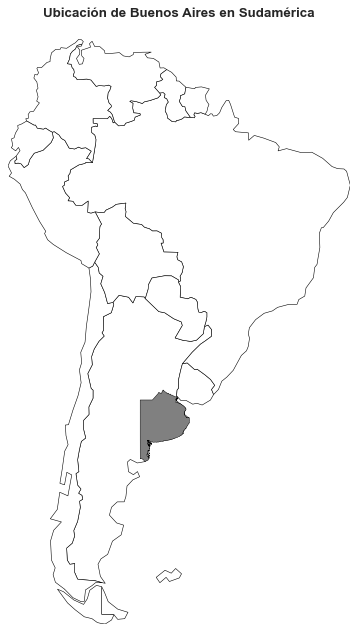

In [23]:
import geopandas as gpd
import matplotlib.pyplot as plt

# -------------------------
# 1. Cargar datos
# -------------------------
paises = gpd.read_file("../data/ne_countries/ne_110m_admin_0_countries.shp")
sudamerica = paises[paises["CONTINENT"] == "South America"]

provincias = gpd.read_file("../data/provincias_ign/provinciaPolygon.shp")
pba = provincias[provincias["nam"] == "Buenos Aires"]

# -------------------------
# 2. PROYECCIÓN (El truco para que no se vea estirado)
# -------------------------
# Pasamos de WGS84 (grados) a Web Mercator (metros), que es el estándar de mapas modernos
sudamerica = sudamerica.to_crs(epsg=3857)
pba = pba.to_crs(epsg=3857)

# -------------------------
# 3. Plot con mejoras estéticas
# -------------------------
# Aumentamos el DPI para que el trazo no se vea "pixelado" o de baja calidad
fig, ax = plt.subplots(figsize=(6, 8), dpi=80)

# Sudamérica (Fondo)
sudamerica.plot(
    ax=ax,
    color="white",      # Un gris muy claro para que no compita con PBA
    edgecolor="black",  # Un gris oscuro en lugar de negro puro (más elegante)
    linewidth=0.5        # Un poco más grueso para que se defina bien
)

# Buenos Aires resaltada
pba.plot(
    ax=ax,
    color="#808080",      # Un dimgray más sólido
    edgecolor="black",
    linewidth=0.4            # Asegura que esté por encima de las líneas de Sudamérica
)

# -------------------------
# 4. Ajustes de encuadre
# -------------------------
# Al cambiar a EPSG:3857, los límites ya no son grados, sino metros. 
# Es mejor dejar que GeoPandas calcule el zoom basado en Sudamérica:
minx, miny, maxx, maxy = sudamerica.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Título con mejor fuente
ax.set_title(
    "Ubicación de Buenos Aires en Sudamérica",
    fontsize=12,
    fontweight="bold",
    pad=20,
    loc="center"
)

ax.axis("off")

plt.tight_layout()
plt.show()

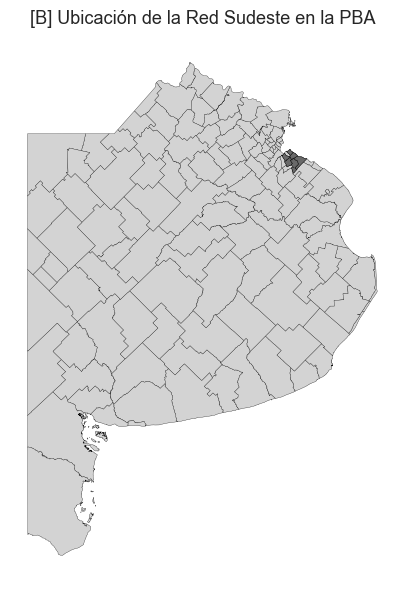

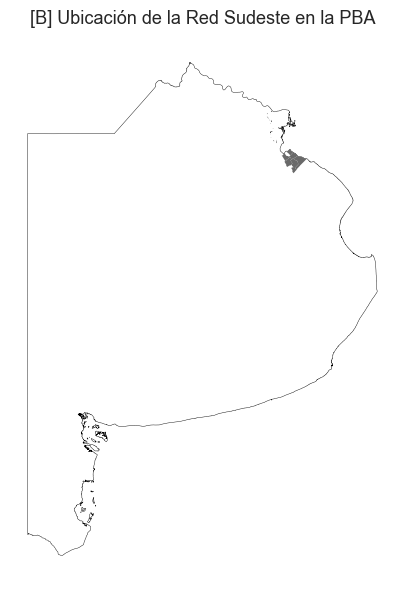

In [24]:
# -------------------------
# cargar municipios (partidos)
# -------------------------
deptos = bases.cargar_municipios("../data/shapefiles/departamento/departamentoPolygon.shp")

# solo partidos de la provincia de buenos aires
pba = deptos[
    deptos["in1"].astype(str).str.startswith("06")
]

# -------------------------
# partidos de la red sudeste
# -------------------------
red_sudeste = [
    "QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA",
    "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "MORON", "ITUZAINGO"
]

sudeste = pba[pba["nam_limpio"].isin(red_sudeste)]

# =====================================================
# OPTION 1
# todos los partidos + red sudeste resaltada
# =====================================================

fig, ax = plt.subplots(figsize=(6,6))

# todos los partidos
pba.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.2
)

# partidos de la red sudeste
sudeste.plot(
    ax=ax,
    color="dimgray",
    edgecolor="black",
    linewidth=0.3
)

ax.set_title(
    "[B] Ubicación de la Red Sudeste en la PBA",
    fontsize=13,
    pad=10
)

ax.axis("off")

plt.tight_layout()
plt.show()


# =====================================================
# OPTION 2
# provincia blanca sin divisiones + red sudeste
# =====================================================

# crear geometría de toda la provincia
pba_union = pba.dissolve()

fig, ax = plt.subplots(figsize=(6,6))

# provincia completa
pba_union.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    linewidth=0.3
)

# partidos de la red
sudeste.plot(
    ax=ax,
    color="dimgray",
    edgecolor="none"
)

ax.set_title(
    "[B] Ubicación de la Red Sudeste en la PBA",
    fontsize=13,
    pad=10
)

ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# C. Los asentamientos cercanos

# RE.NA.BA.P

In [26]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==============================================================================
# CONFIGURACIÓN Y CARGA DE DATOS
# ==============================================================================
# Rutas de los archivos proporcionadas por el usuario. 
# Asegúrate de que los archivos existan en estas ubicaciones.

print("Cargando datos de municipios...")
try:
    deptos = gpd.read_file(RUTA_MUNICIPIOS)
except FileNotFoundError:
    print(f"Error: No se encontró el archivo de municipios en {RUTA_MUNICIPIOS}.")
    print("Por favor, verifica la ruta del archivo.")
    exit()

# Filtrar solo los municipios (partidos) de la provincia de Buenos Aires.
# El código original usa 'bases.cargar_municipios' y un filtrado, 
# pero aquí usamos una carga directa y el filtrado proporcionado.
pba = deptos[
    deptos["in1"].astype(str).str.startswith("06")
]

# Definir los municipios de interés para el enfoque (del código proporcionado)
red_sudeste_names = [
    "QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA",
    "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "MORON", "ITUZAINGO"
]

# Crear una subselección de estos municipios. Usaré 'nam' ya que 'nam_limpio'
# del código original puede depender de una función de limpieza no proporcionada.
# Si tus datos tienen una columna 'nam_limpio', cámbiala aquí.
sudeste = pba[pba["nam"].isin(red_sudeste_names)]

print("Cargando datos de barrios populares (RENABAP)...")
try:
    barrios = gpd.read_file(RUTA_BARRIOS_POPULARES)
except FileNotFoundError:
    print(f"Error: No se encontró el archivo de barrios populares en {RUTA_BARRIOS_POPULARES}.")
    print("Por favor, verifica la ruta del archivo.")
    exit()

# ==============================================================================
# PROYECCIÓN Y FILTRADO ESPACIAL
# ==============================================================================
# Usar la proyección Web Mercator (EPSG:3857) del código proporcionado 
# para mayor precisión y consistencia estética.
print("Proyectando datos a EPSG:3857 (Web Mercator)...")
pba = pba.to_crs(epsg=3857)
sudeste = sudeste.to_crs(epsg=3857)
barrios = barrios.to_crs(epsg=3857)

# Filtrar los barrios populares para que solo se muestren los que están 
# dentro de los municipios de enfoque o dentro de la PBA.
# Para este mapa específico, queremos solo los barrios en los municipios 
# enfocados para que coincida con la imagen.
print("Filtrando barrios populares por municipios de enfoque...")
barrios_enfoque = gpd.sjoin(barrios, sudeste, how="inner", predicate="intersects")

# ==============================================================================
# GRAFICACIÓN CON ESTILO ESTÉTICO
# ==============================================================================
print("Generando mapa...")
# Aumentamos el tamaño y el DPI para mejor calidad, como en el código original.
fig, ax = plt.subplots(figsize=(10, 10), dpi=100)

# 1. Capa de fondo: Límites de TODOS los municipios de la PBA
# Usamos un color de línea gris muy tenue y sin relleno.
pba.plot(
    ax=ax,
    color="none",
    edgecolor="#E0E0E0", # Gris muy tenue (lightgray suave)
    linewidth=0.3
)

# 2. Capa de enfoque: Límites de los municipios seleccionados
# Usamos un borde negro nítido como en la imagen original.
sudeste.plot(
    ax=ax,
    color="none", # Sin relleno para ver el fondo
    edgecolor="black",
    linewidth=0.6,
    zorder=2 # Asegurar que esté por encima del fondo
)

# 3. Capa de barrios populares
# Usamos un color rojo sólido como en la imagen.
barrios_enfoque.plot(
    ax=ax,
    color="red", # Rojo sólido
    edgecolor="none", # Sin borde para evitar que se vea "sucio"
    zorder=3 # Asegurar que esté por encima de los límites municipales
)

# ==============================================================================
# AJUSTES DE ESCENA Y TEXTO [C]
# ==============================================================================
# Desactivar los ejes
ax.axis("off")

# Establecer el encuadre (zoom) basado en la extensión total de los municipios de enfoque.
# Esto asegura que los municipios relevantes y sus barrios sean el centro.
print("Ajustando encuadre...")
minx, miny, maxx, maxy = sudeste.total_bounds
# Añadir un pequeño margen alrededor de los límites para que no toquen el borde.
margen = 0.02 * (maxx - minx)
ax.set_xlim(minx - margen, maxx + margen)
ax.set_ylim(miny - margen, maxy + margen)

# Agregar el cuadro de texto [C] en la esquina superior derecha
print("Agregando cuadro [C]...")
# Usamos coordenadas de transAxes (de 0 a 1) para posicionar.
# (x, y) es la esquina inferior izquierda del rectángulo.
# El rectángulo tiene borde negro y texto blanco.
rect_x, rect_y = 0.8, 0.8
rect_w, rect_h = 0.15, 0.15
rect = patches.Rectangle(
    (rect_x, rect_y), rect_w, rect_h,
    transform=ax.transAxes, # Coordenadas del eje
    facecolor='black',
    alpha=1.0, # Opaco
    edgecolor='black', # Borde nítido
    zorder=10 # Asegurar que esté por encima de todo
)
ax.add_patch(rect)

# Texto dentro del cuadro, centrado.
text_x = rect_x + (rect_w / 2)
text_y = rect_y + (rect_h / 2)
ax.text(
    text_x, text_y,
    "[C]",
    transform=ax.transAxes,
    color='white',
    weight='bold',
    size=30, # Tamaño de fuente grande
    ha='center', va='center',
    zorder=11 # Asegurar que esté por encima del rectángulo
)

# Finalizar y mostrar
print("Mapa completado.")
plt.tight_layout()
plt.show()

Cargando datos de municipios...
Cargando datos de barrios populares (RENABAP)...


DataSourceError: ./data/renabap_geojson/20231205_info_publica.geojson.txt: No such file or directory

In [ ]:

# ----------------------------
# cargar municipios (partidos)
# ----------------------------
deptos = bases.cargar_municipios("../data/shapefiles/departamento/departamentoPolygon.shp")
deptos = deptos.to_crs(pba.crs)  # asegurarse mismo CRS

# solo partidos de la provincia de Buenos Aires
pba = deptos[deptos["in1"].astype(str).str.startswith("06")]

# ----------------------------
# partidos de la red sudeste
# ----------------------------
red_sudeste = [
    "QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA",
    "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "MORON", "ITUZAINGO"
]

sudeste = pba[pba["nam_limpio"].isin(red_sudeste)]
# ----------------------------
# 1. Cargar archivo
# ----------------------------
# leer el archivo original
gdf = gpd.read_file("../data/renabap_geojson/20231205_info_publica.gpkg")  # o .gpkg


# ----------------------------
# 2. Filtrar solo red sudeste
# ----------------------------
# ajustar según tu columna que indique la red
red_sudeste = gdf[gdf["red"] == "sudeste"]

red_sudeste = [
    "QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA",
    "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "MORON", "ITUZAINGO"
]

sudeste = pba[pba["nam_limpio"].isin(red_sudeste)]

KeyError: 'red'

In [ ]:

# ----------------------------
# 3. Guardar como shapefile (opcional)
# ----------------------------
# guardar como shapefile
red_sudeste.to_file("partidos_sudeste.shp")

# ----------------------------
# 4. Cargar la provincia completa
# ----------------------------
provincia = gpd.read_file("provincia_buenos_aires.shp")  # tu shapefile de la provincia

# ----------------------------
# 5. Graficar
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 10))

# provincia de fondo (blanca) con borde negro
provincia.plot(ax=ax, color="white", edgecolor="black", linewidth=1)

# partidos sudeste en gris oscuro, sin bordes internos
red_sudeste.plot(ax=ax, color="dimgray", edgecolor="dimgray", linewidth=0)

# quitar ejes y ticks
ax.set_axis_off()

plt.tight_layout()
plt.show()

Generando red general con filtro de al menos 4 traslados...
Registros luego de filtros: 496
Hospitales origen únicos: 12
Hospitales destino únicos: 12
Nodos en red: 11
Aristas en red: 23

Observaciones:
- Los enlaces restantes solo conectan hospitales del mismo distrito, con la excepción de 'El Cruce'.
- 'Evita Pueblo' y 'UPA 10-BE' quedan aislados de la red principal.


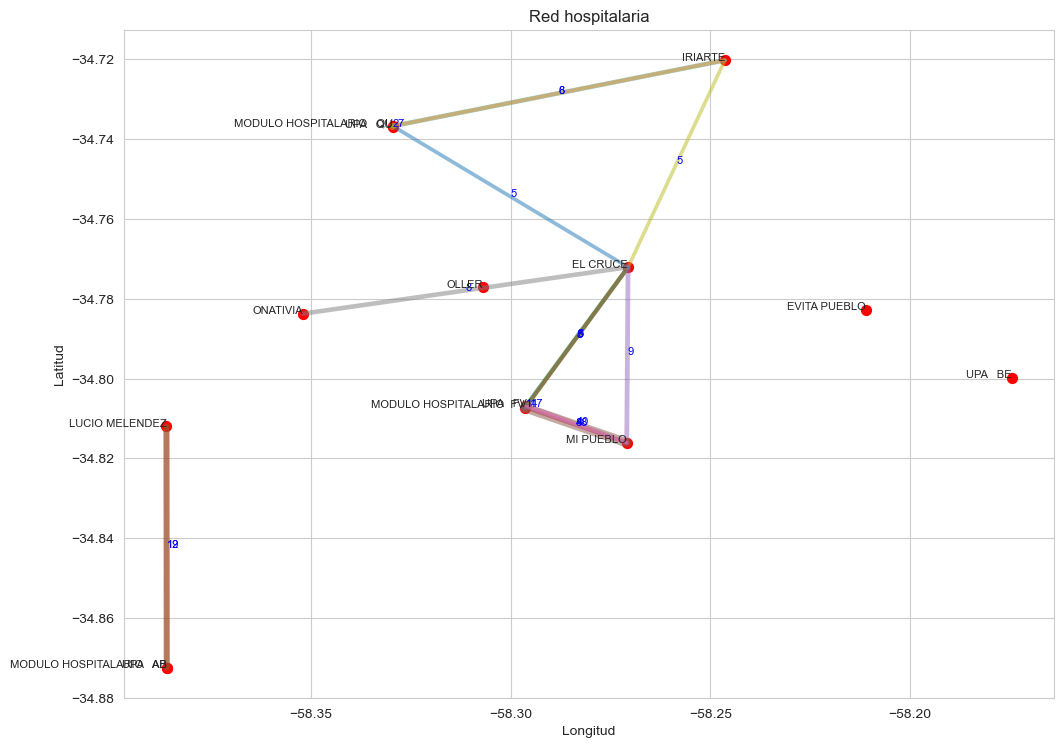

In [ ]:
# Red General (Panel D)
# Armar el grafo dirigido y pesado para todo el período
print("Generando red general con filtro de al menos 4 traslados...")
G, edges, fig_tuple = bases.analizar_red_hospitalaria(
    traslados, hosp_coords, 
    peso_minimo=4, # Filtro aplicado
    modo="estatico", 
    mostrar_resumen=True, 
    graficar=True
)

# Observaciones de la red
print("\nObservaciones:")
print("- Los enlaces restantes solo conectan hospitales del mismo distrito, con la excepción de 'El Cruce'.")
print("- 'Evita Pueblo' y 'UPA 10-BE' quedan aislados de la red principal.")

# Rutas (Panel E)
# Generar la red de los dos caminos más cortos desde cada hospital a través de las calles.


In [ ]:
# Rutas (Panel E)
# Generar la red de los dos caminos más cortos desde cada hospital a través de las calles.


## Inpatients Flow throughout Time.

Se divide el período en cuatro etapas: First Wave, Intermediate, Second Wave y Post Vaccination Stage. Existe concordancia entre la evolución de los ingresos y los traslados a lo largo del período.


In [ ]:
# Gráfico de Series Temporales
# Gráfico de líneas con doble eje Y: "Admissions" (en rojo) y "Transfers" (en negro) desde abril de 2020 hasta diciembre de 2022.
# Sombras/líneas para delimitar el "National Lockdown" y las cuatro etapas mencionadas:
# 1. First Wave
# 2. Intermediate
# 3. Second Wave
# 4. Post Vaccination Stage


## Hospital Network: Evolution Throughout the Different Stages.

Se construyó una red separada para cada etapa pandémica y los nodos correspondientes a Módulos Hospitalarios y UPAs fueron separados.

**Hallazgos clave:**
- Los traslados UPA-Módulo aumentaron de la primera a la segunda ola, a pesar de que los ingresos y traslados totales fueron similares en ambas olas.
- Hubo una caída abrupta en la distancia total y mediana recorrida de la primera a la segunda ola, reflejando un aumento en la eficiencia de la red.
- En la etapa post-vacunación, se observó la esperada caída en el porcentaje de traslados sobre ingresos.


In [ ]:
# Tabla Resumen por Etapas
import numpy as np

# Estructura inicial del DataFrame para recopilar las métricas de las 4 etapas
tabla_datos = {
    'Metric': [
        'Total days', 
        'Admissions', 
        'Total transfers (%)', 
        'Ambulance transfers (%)', 
        'N of total edges | N of ambulance edges', 
        'N of transfers by edge | N of ambulance transfers by edge', 
        'Total traveled distance / Median distance'
    ],
    'First Wave': [np.nan] * 7,
    'Intermediate': [np.nan] * 7,
    'Second Wave': [np.nan] * 7,
    'Post-Vaccination Stage': [np.nan] * 7
}

df_resumen = pd.DataFrame(tabla_datos)
df_resumen.set_index('Metric', inplace=True)

# Completar con la información a medida que se procesen las etapas
display(df_resumen)


,First Wave,Intermediate,Second Wave,Post-Vaccination Stage
Metric,,,,
Total days,NaN,NaN,NaN,NaN
Admissions,NaN,NaN,NaN,NaN
Total transfers (%),NaN,NaN,NaN,NaN
Ambulance transfers (%),NaN,NaN,NaN,NaN
N of total edges | N of ambulance edges,NaN,NaN,NaN,NaN
N of transfers by edge | N of ambulance transfers by edge,NaN,NaN,NaN,NaN
Total traveled distance / Median distance,NaN,NaN,NaN,NaN


In [ ]:
# Sub-Grafos por Etapa
# Cuadrícula con 4 gráficos de red (una para cada etapa temporal)
# Tamaño de los nodos varían según la respectiva etapa para Oñativia, El Cruce, Mi Pueblo, etc.


## Inpatients Days and Topological Role / Source/Sink Role (SSR).

El rol topológico de cada hospital (Source/Sink Role) se calcula con la siguiente fórmula:

$$ssr_{i}=\frac{t_{i}^{in}-t_{i}^{out}}{t_{i}^{in}+t_{i}^{out}}$$

Donde $t_{i}^{in}$ y $t_{i}^{out}$ son los ingresos y egresos por traslados. Un valor de $ssr_{i}=1$ significa que el hospital es una fuente pura ("pure source"), mientras que $ssr_{j}=-1$ indica un sumidero puro ("pure sink").

**Clustering:** Al estudiar el SSR, surge un agrupamiento (clustering) debido a los diferentes niveles de complejidad de los hospitales.


In [ ]:
# Cálculo y Visualización del SSR
# Aplicar la fórmula del SSR a los datos.
# Generar un gráfico (scatter plot o barras) mostrando el espectro de -1 a 1 para evidenciar clústers de complejidad.


## Bibliography

1. Alvarez et al.
2. Yacobitti et al.
3. [Instituto del Cálculo (UBA-CONICET)](https://ic.fcen.uba.ar/)
4. Kohler et al.
5. Rocha et al.
